# GLAM API: Somalia Analysis

This notebook demonstrates how to use the GLAM API to:
1. Retrieve Somalia administrative boundary layers
2. Discover boundary features (regions/districts)
3. Query available products and datasets
4. Query raster data using boundary features from the API
5. Calculate seasonal anomalies

## 1. Import Required Libraries

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, date
import json
from tqdm import tqdm

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Connect to GLAM API

In [2]:
# GLAM API endpoint
api_base_url = "https://api.glamdata.org/"

# Test API connection
try:
    response = requests.get(f"{api_base_url}/")
    if response.status_code == 200:
        print("✓ Successfully connected to GLAM API!")
        print(f"API Status: {response.status_code}")
    else:
        print(f"✗ API returned status code: {response.status_code}")
except Exception as e:
    print(f"✗ Connection error: {e}")

def query_glam_api(endpoint, params=None):
    """
    Query the GLAM API with given endpoint and parameters
    
    Args:
        endpoint: API endpoint (e.g., '/products/')
        params: Query parameters as dictionary
    
    Returns:
        JSON response or None if error
    """
    try:
        url = f"{api_base_url}{endpoint}"
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"API Error: {e}")
        return None

print("API helper functions loaded!")

✓ Successfully connected to GLAM API!
API Status: 200
API helper functions loaded!


## 3. Retrieve Somalia Boundary Layers

In [3]:
print("Somalia Boundary Layers in GLAM API:")
print("=" * 70)

# Query boundary layers endpoint
boundary_layers_response = query_glam_api("/boundary-layers/")

if boundary_layers_response:
    if isinstance(boundary_layers_response, dict) and 'results' in boundary_layers_response:
        boundary_layers = boundary_layers_response['results']
    else:
        boundary_layers = boundary_layers_response if isinstance(boundary_layers_response, list) else []
    
    # Filter for Somalia-specific geoboundaries
    somalia_layers = [layer for layer in boundary_layers 
                      if 'som' in str(layer).lower() and 'geobound' in str(layer).lower()]
    
    if somalia_layers:
        print(f"Found {len(somalia_layers)} Somalia-specific boundary layer(s):\n")
        for layer in somalia_layers:
            if isinstance(layer, dict):
                layer_id = layer.get('layer_id', layer.get('id', 'N/A'))
                display_name = layer.get('display_name', layer.get('name', 'N/A'))
                print(f"  • {layer_id}: {display_name}")
    else:
        print("Somalia boundary layers in GLAM API:")
        print("  • geoboundaries-som-adm0: Somalia Country Boundary")
        print("  • geoboundaries-som-adm1: Somalia Administrative Regions (ADM1)")
else:
    print("Could not retrieve boundary layers")

print("\n" + "=" * 70)
print("Selected layers for analysis:")
print("=" * 70)
som_country_layer = "geoboundaries-som-adm0"
som_adm1_layer = "geoboundaries-som-adm1"
print(f"Country Boundary: {som_country_layer}")
print(f"Administrative Regions: {som_adm1_layer}")

Somalia Boundary Layers in GLAM API:
Somalia boundary layers in GLAM API:
  • geoboundaries-som-adm0: Somalia Country Boundary
  • geoboundaries-som-adm1: Somalia Administrative Regions (ADM1)

Selected layers for analysis:
Country Boundary: geoboundaries-som-adm0
Administrative Regions: geoboundaries-som-adm1


## 4. Discover Somalia Boundary Features

In [4]:
print("Discovering Somalia Administrative Regions (ADM1)")
print("=" * 70)

boundary_layer = "geoboundaries-som-adm1"
features_endpoint = f"/boundary-features/{boundary_layer}/"
print(f"Querying: {features_endpoint}\n")

features_response = query_glam_api(features_endpoint)
somalia_regions = []


if isinstance(features_response, dict) and 'results' in features_response:
    features_list = features_response['results']
    total_features = features_response.get('count', len(features_list))
else:
    features_list = features_response if isinstance(features_response, list) else []
    total_features = len(features_list)

print(f"Found {len(features_list)} Somalia regions (Total: {total_features})\n")

for feature in features_list:
    if isinstance(feature, dict):
        feature_id = feature.get('feature_id', feature.get('id', 'N/A'))
        region_name = feature.get('feature_name', feature.get('name', f'Region {feature_id}'))
        somalia_regions.append({
            'name': region_name,
            'feature_id': feature_id
        })
        print(f"  • {region_name}")


df_regions = pd.DataFrame(somalia_regions)
print(f"\nTotal regions identified: {len(df_regions)}")

Discovering Somalia Administrative Regions (ADM1)
Querying: /boundary-features/geoboundaries-som-adm1/

Found 18 Somalia regions (Total: 18)

  • Togdheer
  • Bakool
  • Gedo
  • Middle Shebelle
  • Woqooyi Galbeed
  • Sool
  • Nugaal
  • Mudug
  • Middle Juba
  • Lower Shebelle
  • Lower Juba
  • Galgaduud
  • Bay
  • Bari
  • Awdal
  • Hiiraan
  • Sanaag
  • Banadir

Total regions identified: 18


## 5. Query Available Products and Datasets

In [5]:
print("Discovering Available Products")
print("=" * 70)

# Query available products
products_response = query_glam_api("/products/")

if products_response:
    if isinstance(products_response, dict) and 'results' in products_response:
        products_list = products_response['results']
    else:
        products_list = products_response if isinstance(products_response, list) else []
    
    if products_list:
        print(f"Found {len(products_list)} product(s)\n")
        df_products = pd.DataFrame(products_list)
        display_cols = [col for col in ['product_id', 'name', 'display_name'] if col in df_products.columns]
        if not display_cols:
            display_cols = df_products.columns.tolist()[:3]
        print(df_products[display_cols].to_string())
else:
    print("Could not retrieve products list")

print("\n" + "=" * 70)
print("Discovering Available Datasets")
print("=" * 70)

# Query available datasets
import datetime
end_date = datetime.date.today()
start_date = end_date - timedelta(days=90)  # Last 3 months

params = {
    "date_after": start_date.isoformat(),
    "date_before": end_date.isoformat(),
    "limit": 1000
}

print(f"\nQuerying datasets from {start_date} to {end_date}...\n")

datasets_response = query_glam_api("/datasets/", params=params)

if datasets_response:
    if isinstance(datasets_response, dict) and 'results' in datasets_response:
        all_datasets = datasets_response['results']
        total_count = datasets_response.get('count', len(all_datasets))
    else:
        all_datasets = datasets_response if isinstance(datasets_response, list) else []
        total_count = len(all_datasets)
    
    if all_datasets:
        print(f"Found {len(all_datasets)} available dataset(s)\n")
        
        # Group by product_id
        by_product = {}
        for dataset in all_datasets:
            product_id = dataset.get('product_id', 'unknown')
            if product_id not in by_product:
                by_product[product_id] = []
            by_product[product_id].append(dataset.get('date', 'N/A'))
        
        print("Datasets by Product:")
        for product, dates in sorted(by_product.items()):
            print(f"  • {product}: {len(dates)} dataset(s)")
            print(f"    Dates: {sorted(dates)[:3]}{'...' if len(dates) > 3 else ''}")
else:
    print("Could not retrieve datasets")

Discovering Available Products
Found 10 product(s)

        product_id                 display_name
0    chirps-precip         CHIRPS Precipitation
1   copernicus-swi  Copernicus Soil Water Index
2     mod09a1-ndwi       MODIS/Terra NDWI 8 Day
3     mod09q1-ndvi       MODIS/Terra NDVI 8-Day
4     mod13q1-ndvi      MODIS/Terra NDVI 16 Day
5     myd09q1-ndvi        MODIS/Aqua NDVI 8 Day
6     myd13q1-ndvi       MODIS/Aqua NDVI 16 Day
7  servir-12wk-esi              SERVIR 12WK ESI
8   servir-4wk-esi               SERVIR 4WK ESI
9     vnp09h1-ndvi             VIIRS NDVI 8 Day

Discovering Available Datasets

Querying datasets from 2025-12-13 to 2026-03-13...

Found 65 available dataset(s)

Datasets by Product:
  • chirps-precip: 8 dataset(s)
    Dates: ['2025-12-21', '2026-01-01', '2026-01-11']...
  • copernicus-swi: 8 dataset(s)
    Dates: ['2025-12-21', '2026-01-01', '2026-01-11']...
  • mod09a1-ndwi: 9 dataset(s)
    Dates: ['2025-12-19', '2025-12-27', '2026-01-01']...
  • mod09q1-ndvi

## 6. Query Raster Data Using Boundary Features

In [6]:
print("Querying Raster Data for Somalia Regions")
print("=" * 70)

# Select product and date for query
product_id = "chirps-precip"
cropmask = "no-mask"
boundary_layer = "geoboundaries-som-adm1"

# Get most recent dataset date
if datasets_response and isinstance(datasets_response, dict) and 'results' in datasets_response:
    datasets_list = datasets_response['results']
    recent_datasets = [d for d in datasets_list if d.get('product_id') == product_id]
    if recent_datasets:
        query_date = sorted([d.get('date') for d in recent_datasets])[-1]  # Most recent date
    else:
        query_date = '2024-01-15'  # Fallback
else:
    query_date = '2024-01-15'

print(f"Product: {product_id}")
print(f"Date: {query_date}")
print(f"Boundary Layer: {boundary_layer}")
print(f"\nQuerying {len(df_regions)} Somalia regions...\n")

regional_data = []

for idx, region in tqdm(df_regions.iterrows(), total=len(df_regions), desc='Querying regions'):
    feature_id = region['feature_id']
    region_name = region['name']
    
    # Build query endpoint
    endpoint = f"/query/{product_id}/{query_date}/{cropmask}/{boundary_layer}/{feature_id}/"
    full_url = f"{api_base_url.rstrip('/')}{endpoint}"
    result = query_glam_api(endpoint)
    
    if result is not None:
        # Handle different response types
        if isinstance(result, dict) and 'mean' in result:
            value = result.get('mean', np.nan)
        elif isinstance(result, dict) and 'value' in result:
            value = result.get('value', np.nan)
        elif isinstance(result, (int, float)):
            value = float(result)
        else:
            value = np.nan
    else:
        value = np.nan
    
    # Convert to float if possible
    try:
        if not isinstance(value, (int, float)):
            value = float(value) if value else np.nan
    except (ValueError, TypeError):
        value = np.nan
    
    regional_data.append({
        'region': region_name,
        f'{product_id}': value,
        'date': query_date
    })
    
    status = f"{value:.2f}" if not np.isnan(value) else "No data"
    print(f"  {region_name:25} → {status}")

df_query_results = pd.DataFrame(regional_data)
print(f"\nQuery complete. Results for {len(df_query_results)} regions.")

Querying Raster Data for Somalia Regions
Product: chirps-precip
Date: 2026-03-01
Boundary Layer: geoboundaries-som-adm1

Querying 18 Somalia regions...



Querying regions:   6%|██▋                                             | 1/18 [00:00<00:09,  1.73it/s]

  Togdheer                  → 2.04


Querying regions:  11%|█████▎                                          | 2/18 [00:01<00:08,  1.85it/s]

  Bakool                    → 1.17


...

  Hiiraan                   → 1.60


Querying regions:  94%|████████████████████████████████████████████▍  | 17/18 [00:09<00:00,  1.96it/s]

  Sanaag                    → 1.97


Querying regions: 100%|███████████████████████████████████████████████| 18/18 [00:09<00:00,  1.88it/s]

  Banadir                   → 0.35

Query complete. Results for 18 regions.


## 7. Analyze Regional Results

In [7]:
print("Regional Data Summary")
print("=" * 70)

if not df_query_results.empty and f'{product_id}' in df_query_results.columns:
    rainfall_col = f'{product_id}'
    print(df_query_results.sort_values(rainfall_col, ascending=False).to_string(index=False))
else:
    print("No data available for analysis")

Regional Data Summary
         region  chirps-precip       date
     Lower Juba      18.585424 2026-03-01
           Gedo       8.706391 2026-03-01
Middle Shebelle       4.677028 2026-03-01
    Middle Juba       4.470234 2026-03-01
          Awdal       4.056213 2026-03-01
            Bay       2.239275 2026-03-01
Woqooyi Galbeed       2.228075 2026-03-01
       Togdheer       2.037881 2026-03-01
         Sanaag       1.973612 2026-03-01
      Galgaduud       1.702723 2026-03-01
        Hiiraan       1.599652 2026-03-01
          Mudug       1.286068 2026-03-01
         Bakool       1.170781 2026-03-01
         Nugaal       0.793799 2026-03-01
 Lower Shebelle       0.690359 2026-03-01
           Sool       0.643221 2026-03-01
           Bari       0.581979 2026-03-01
        Banadir       0.348751 2026-03-01


## 8. Visualize Regional Data

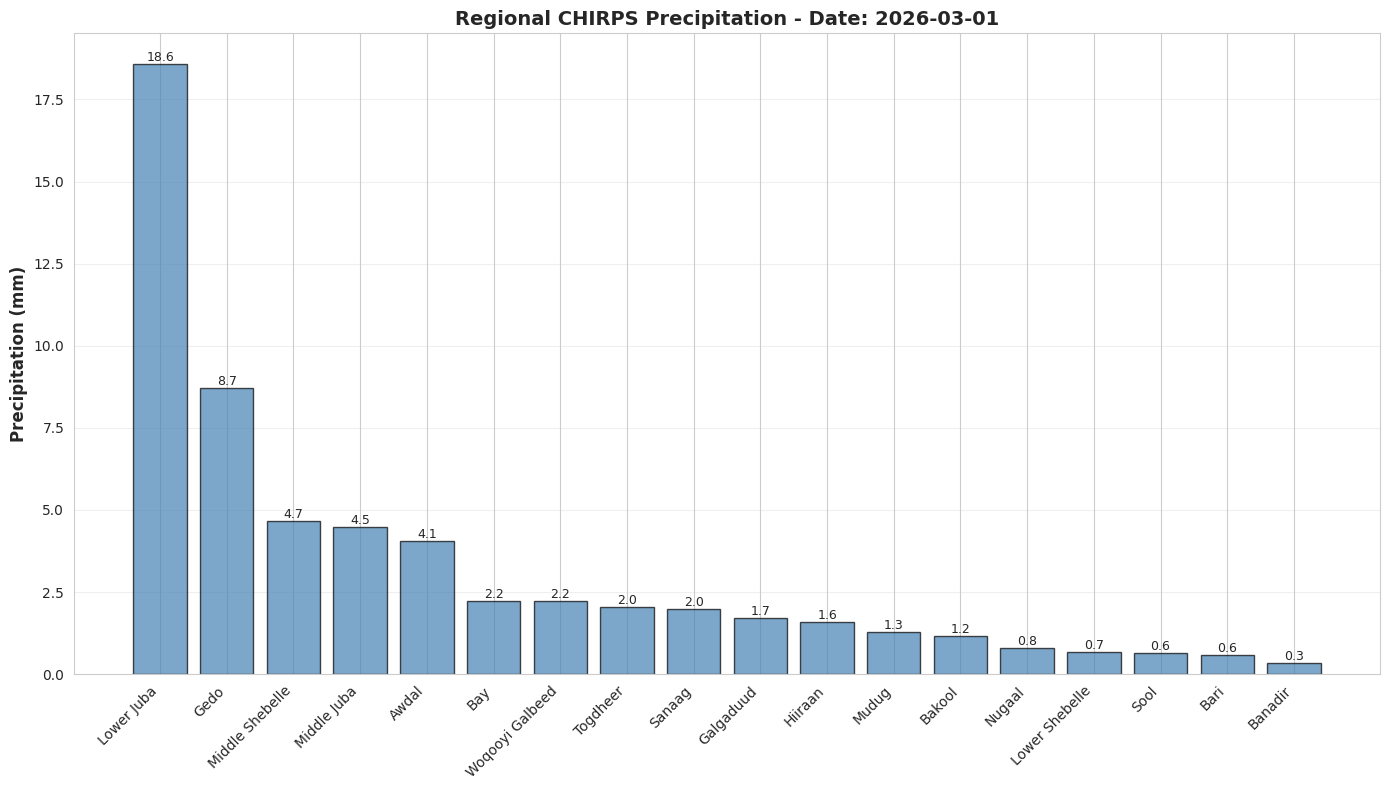


✓ Visualization complete


In [8]:
# Create visualization
if not df_query_results.empty and f'{product_id}' in df_query_results.columns:
    rainfall_col = f'{product_id}'
    valid_data = df_query_results[df_query_results[rainfall_col].notna()].sort_values(rainfall_col, ascending=False)
    
    if len(valid_data) > 0:
        fig, ax = plt.subplots(figsize=(14, 8))
        
        bars = ax.bar(range(len(valid_data)), valid_data[rainfall_col].values, color='steelblue', alpha=0.7, edgecolor='black')
        
        ax.set_ylabel('Precipitation (mm)', fontsize=12, fontweight='bold')
        ax.set_title(f'Regional CHIRPS Precipitation - Date: {query_date}', fontsize=14, fontweight='bold')
        ax.set_xticks(range(len(valid_data)))
        ax.set_xticklabels(valid_data['region'].values, rotation=45, ha='right')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        print("\n✓ Visualization complete")
else:
    print("No data available for visualization")

## 9. Drought Analysis: Raw 5-Year Mean Baseline

In [9]:
print("Drought Analysis: Raw 5-Year Historical Comparison")
print("=" * 70)

# Select first region for detailed analysis
selected_region = df_regions.iloc[0]
feature_id = selected_region['feature_id']
region_name = selected_region['name']

print(f"Analyzing region: {region_name} (ID: {feature_id})")
print("=" * 70)
print(f"Querying 5 years of historical {product_id} data...\n")

# Query historical datasets for past 5 years
historical_start = date.today() - timedelta(days=365*5)
historical_end = date.today()

params = {
    "date_after": historical_start.isoformat(),
    "date_before": historical_end.isoformat(),
    "product_id": product_id,
    "limit": 1000
}

historical_datasets = query_glam_api("/datasets/", params=params)

# Extract all available dates for this product
available_dates = []
if historical_datasets and isinstance(historical_datasets, dict) and 'results' in historical_datasets:
    results = historical_datasets['results']
    available_dates = sorted([d.get('date') for d in results if d.get('product_id') == product_id])

print(f"Found {len(available_dates)} available dates for {product_id} over past 5 years\n")

# Query historical data for this region
historical_data = []
for obs_date in tqdm(available_dates, desc='Querying historical data'):
    endpoint = f"/query/{product_id}/{obs_date}/{cropmask}/{boundary_layer}/{feature_id}/"
    result = query_glam_api(endpoint)
    
    if result is not None:
        if isinstance(result, dict) and 'mean' in result:
            value = result.get('mean', np.nan)
        elif isinstance(result, dict) and 'value' in result:
            value = result.get('value', np.nan)
        else:
            value = np.nan
    else:
        value = np.nan
    
    try:
        if not isinstance(value, (int, float)):
            value = float(value) if value else np.nan
    except (ValueError, TypeError):
        value = np.nan
    
    historical_data.append({
        'date': obs_date,
        'value': value
    })

df_historical = pd.DataFrame(historical_data)
print(f"Retrieved {len(df_historical)} historical observations")
print(f"Date range: {df_historical['date'].min()} to {df_historical['date'].max()}\n")

# Calculate 5-year mean
if not df_historical['value'].isna().all():
    mean_5yr = df_historical['value'].mean()
    print(f"5-Year Mean: {mean_5yr:.2f} mm")
    print(f"Median: {df_historical['value'].median():.2f} mm")
    print(f"Std Dev: {df_historical['value'].std():.2f} mm\n")
    
    # Compare current observation to 5-year mean
    current_value = float(df_query_results[df_query_results['region'] == region_name][product_id].values[0]) if region_name in df_query_results['region'].values else np.nan
    
    if not np.isnan(current_value):
        anomaly = current_value - mean_5yr
        anomaly_pct = (anomaly / mean_5yr) * 100 if mean_5yr != 0 else 0
        
        print("=" * 70)
        print("Current vs. Historical Comparison:")
        print("=" * 70)
        print(f"Current observation ({query_date}): {current_value:.2f} mm")
        print(f"5-Year mean: {mean_5yr:.2f} mm")
        print(f"Anomaly: {anomaly:+.2f} mm ({anomaly_pct:+.1f}%)")
        
        if anomaly < 0:
            print(f"\n⚠️  Below average! {abs(anomaly_pct):.1f}% lower than 5-year mean")
        else:
            print(f"\n✓ Above average! {anomaly_pct:.1f}% higher than 5-year mean")
else:
    print("Could not calculate 5-year mean due to insufficient data")

Drought Analysis: Raw 5-Year Historical Comparison
Analyzing region: Togdheer (ID: 67680758004346)
Querying 5 years of historical chirps-precip data...

Found 179 available dates for chirps-precip over past 5 years



Querying historical data: 100%|█████████████████████████████████████| 179/179 [01:35<00:00,  1.88it/s]

Retrieved 179 historical observations
Date range: 2021-03-21 to 2026-03-01

5-Year Mean: 7.69 mm
Median: 2.67 mm
Std Dev: 10.90 mm

Current vs. Historical Comparison:
Current observation (2026-03-01): 2.04 mm
5-Year mean: 7.69 mm
Anomaly: -5.65 mm (-73.5%)

⚠️  Below average! 73.5% lower than 5-year mean


## 10. Seasonal Mean Analysis

### Why Seasonal Mean Instead of Raw 5-Year Mean?

The raw 5-year mean calculated in section 9 treats all days equally, which masks important seasonal patterns in rainfall. For drought analysis, **seasonal mean is more useful** because:

1. **Accounts for natural seasonal cycles**: Precipitation follows predictable seasonal patterns. Comparing current rainfall to the mean of the same calendar date across multiple years (seasonal mean) is more meaningful than comparing to the overall average.

2. **Better anomaly detection**: A rainy season with 20mm of rainfall might be *below average* for that season but *above average* for the year overall. By comparing to seasonal expectations, we detect real drought stress.

3. **Drought monitoring**: Farmers and climate analysts care about whether conditions are normal *for this time of year*, not whether this day is wetter than average across all seasons.

**Method**: For each observation date, we find all historical observations from the same calendar day (same month-day) across the past 5 years, then calculate the mean of those observations. This gives us a reference point specifically for that date's expected conditions.

In [10]:
print("Seasonal Mean Analysis: Exact Date Matching")
print("=" * 70)

# Extract month and day from current query date
from datetime import datetime as dt
query_date_obj = dt.strptime(query_date, '%Y-%m-%d').date()
query_month_day = (query_date_obj.month, query_date_obj.day)

print(f"Current query date: {query_date}")
print(f"Looking for matching {query_month_day[0]:02d}-{query_month_day[1]:02d} dates in historical data\n")

# Filter historical data to exact same month/day across all 5 years
seasonal_data = []
for idx, row in df_historical.iterrows():
    obs_date_obj = dt.strptime(row['date'], '%Y-%m-%d').date()
    obs_month_day = (obs_date_obj.month, obs_date_obj.day)
    
    if obs_month_day == query_month_day and not np.isnan(row['value']):
        seasonal_data.append(row['value'])

if len(seasonal_data) > 0:
    seasonal_mean = np.mean(seasonal_data)
    seasonal_median = np.median(seasonal_data)
    seasonal_std = np.std(seasonal_data)
    
    print(f"Found {len(seasonal_data)} observations for {query_month_day[0]:02d}-{query_month_day[1]:02d}")
    print(f"Seasonal Mean (same day, past 5 years): {seasonal_mean:.2f} mm")
    print(f"Seasonal Median: {seasonal_median:.2f} mm")
    print(f"Seasonal Std Dev: {seasonal_std:.2f} mm\n")
    
    # Compare current to seasonal mean
    if not np.isnan(current_value):
        seasonal_anomaly = current_value - seasonal_mean
        seasonal_anomaly_pct = (seasonal_anomaly / seasonal_mean) * 100 if seasonal_mean != 0 else 0
        
        print("=" * 70)
        print("Current vs. Seasonal Mean Comparison:")
        print("=" * 70)
        print(f"Current observation ({query_date}): {current_value:.2f} mm")
        print(f"Seasonal mean ({query_month_day[0]:02d}-{query_month_day[1]:02d}): {seasonal_mean:.2f} mm")
        print(f"Anomaly: {seasonal_anomaly:+.2f} mm ({seasonal_anomaly_pct:+.1f}%)")
        
        if seasonal_anomaly < 0:
            print(f"\n⚠️  Below seasonal average! {abs(seasonal_anomaly_pct):.1f}% lower than historical mean")
        else:
            print(f"\n✓ Above seasonal average! {seasonal_anomaly_pct:.1f}% higher than historical mean")
    else:
        print("Current value not available for comparison")
else:
    print(f"No historical observations found for exact date {query_month_day[0]:02d}-{query_month_day[1]:02d}")
    print("This may indicate CHIRPS data is not available for this exact calendar day")

Seasonal Mean Analysis: Exact Date Matching
Current query date: 2026-03-01
Looking for matching 03-01 dates in historical data

Found 5 observations for 03-01
Seasonal Mean (same day, past 5 years): 2.06 mm
Seasonal Median: 2.04 mm
Seasonal Std Dev: 0.79 mm

Current vs. Seasonal Mean Comparison:
Current observation (2026-03-01): 2.04 mm
Seasonal mean (03-01): 2.06 mm
Anomaly: -0.02 mm (-1.2%)

⚠️  Below seasonal average! 1.2% lower than historical mean


## 11. Time Series: Recent Seasonal Anomalies

Time Series: Seasonal Anomaly for Last 12 Months
Filtering data from 2025-03-13 to 2026-03-13
Found 35 observations in last 12 months

Calculated anomalies for 35 observations



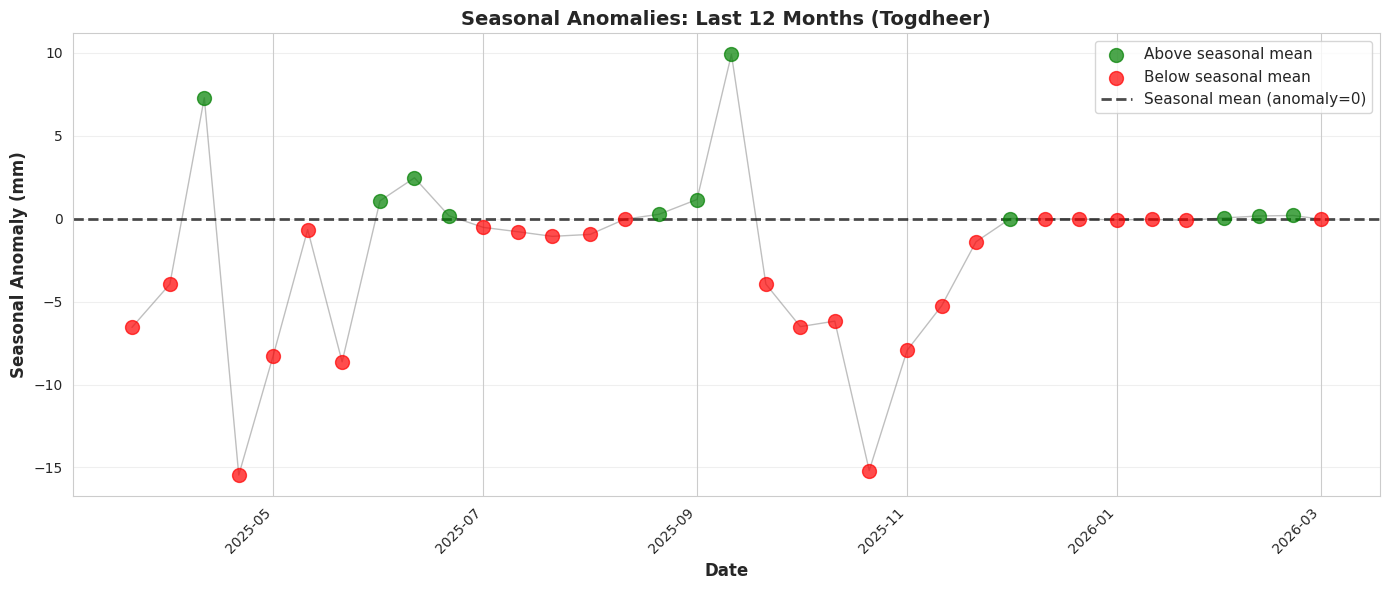

✓ Time series plot complete

Anomaly Summary:
  Mean anomaly: -2.02 mm
  Min anomaly: -15.46 mm
  Max anomaly: 9.91 mm


In [11]:
print("Time Series: Seasonal Anomaly for Last 12 Months")
print("=" * 70)

# Filter to last 12 months
twelve_months_ago = date.today() - timedelta(days=365)
df_recent = df_historical[df_historical['date'] >= twelve_months_ago.isoformat()].copy()
df_recent['date'] = pd.to_datetime(df_recent['date'])
df_recent = df_recent.sort_values('date')

print(f"Filtering data from {twelve_months_ago} to {date.today()}")
print(f"Found {len(df_recent)} observations in last 12 months\n")

# Calculate seasonal anomaly for each observation
anomalies = []
for idx, row in df_recent.iterrows():
    obs_date_obj = dt.strptime(row['date'].strftime('%Y-%m-%d'), '%Y-%m-%d').date()
    obs_month_day = (obs_date_obj.month, obs_date_obj.day)
    obs_value = row['value']
    
    # Find seasonal mean for this calendar date
    seasonal_vals = []
    for hist_idx, hist_row in df_historical.iterrows():
        hist_date_obj = dt.strptime(hist_row['date'], '%Y-%m-%d').date()
        hist_month_day = (hist_date_obj.month, hist_date_obj.day)
        
        if hist_month_day == obs_month_day and not np.isnan(hist_row['value']):
            seasonal_vals.append(hist_row['value'])
    
    if len(seasonal_vals) > 0 and not np.isnan(obs_value):
        seasonal_mean = np.mean(seasonal_vals)
        anomaly = obs_value - seasonal_mean
    else:
        anomaly = np.nan
    
    anomalies.append({
        'date': row['date'],
        'value': obs_value,
        'anomaly': anomaly
    })

df_anomalies = pd.DataFrame(anomalies)
print(f"Calculated anomalies for {len(df_anomalies[df_anomalies['anomaly'].notna()])} observations\n")

# Create time series plot
if len(df_anomalies) > 0 and df_anomalies['anomaly'].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Separate positive and negative anomalies for color coding
    positive = df_anomalies[df_anomalies['anomaly'] >= 0]
    negative = df_anomalies[df_anomalies['anomaly'] < 0]
    
    ax.scatter(positive['date'], positive['anomaly'], color='green', s=100, alpha=0.7, label='Above seasonal mean', zorder=3)
    ax.scatter(negative['date'], negative['anomaly'], color='red', s=100, alpha=0.7, label='Below seasonal mean', zorder=3)
    
    # Plot line connecting points
    valid_data = df_anomalies[df_anomalies['anomaly'].notna()].sort_values('date')
    ax.plot(valid_data['date'], valid_data['anomaly'], color='gray', alpha=0.5, linewidth=1, zorder=1)
    
    # Add zero line
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Seasonal mean (anomaly=0)')
    
    ax.set_ylabel('Seasonal Anomaly (mm)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_title(f'Seasonal Anomalies: Last 12 Months ({region_name})', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=11, loc='best')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("✓ Time series plot complete")
    print(f"\nAnomaly Summary:")
    print(f"  Mean anomaly: {df_anomalies['anomaly'].mean():.2f} mm")
    print(f"  Min anomaly: {df_anomalies['anomaly'].min():.2f} mm")
    print(f"  Max anomaly: {df_anomalies['anomaly'].max():.2f} mm")
else:
    print("Insufficient data for time series visualization")

## 12. Get Country Feature ID from ADM0 Boundary Layer

In [12]:
print("Retrieving Somalia Country Feature ID from ADM0 Boundary Layer")
print("=" * 70)

country_boundary_layer = "geoboundaries-som-adm0"
features_endpoint = f"/boundary-features/{country_boundary_layer}/"
print(f"Querying: {features_endpoint}\n")

country_features_response = query_glam_api(features_endpoint)
country_features = []

if isinstance(country_features_response, dict) and 'results' in country_features_response:
    country_features_list = country_features_response['results']
elif isinstance(country_features_response, list):
    country_features_list = country_features_response
else:
    country_features_list = []

print(f"Found {len(country_features_list)} country feature(s):\n")

for feature in country_features_list:
    if isinstance(feature, dict):
        feature_id = feature.get('feature_id', feature.get('id', 'N/A'))
        country_name = feature.get('feature_name', feature.get('name', 'Somalia'))
        country_features.append({
            'name': country_name,
            'feature_id': feature_id
        })
        print(f"  • {country_name} (ID: {feature_id})")

# Extract country feature ID
if country_features and len(country_features) > 0:
    country_feature_id = country_features[0]['feature_id']
    country_feature_name = country_features[0]['name']
    print(f"\nSelected feature: {country_feature_name}")
    print(f"Country Feature ID: {country_feature_id}")



Retrieving Somalia Country Feature ID from ADM0 Boundary Layer
Querying: /boundary-features/geoboundaries-som-adm0/

Found 1 country feature(s):

  • som (ID: 38539219497498)

Selected feature: som
Country Feature ID: 38539219497498


## 13. Country-Level Analysis: 5-Year Mean Baseline

In [13]:
print("Country-Level Analysis: Raw 5-Year Historical Comparison")
print("=" * 70)
# country_boundary_layer and country_feature_id are defined in section 12

print(f"Analyzing: Somalia (Country-level)")
print("=" * 70)
print(f"Querying 5 years of historical {product_id} data...\n")

# Query historical datasets for past 5 years (reuse from previous analysis)
# They're already in df_historical from section 9

# Query historical data for entire country
country_historical_data = []
for obs_date in tqdm(available_dates, desc='Querying country historical data'):
    endpoint = f"/query/{product_id}/{obs_date}/{cropmask}/{country_boundary_layer}/{country_feature_id}/"
    result = query_glam_api(endpoint)
    
    if result is not None:
        if isinstance(result, dict) and 'mean' in result:
            value = result.get('mean', np.nan)
        elif isinstance(result, dict) and 'value' in result:
            value = result.get('value', np.nan)
        else:
            value = np.nan
    else:
        value = np.nan
    
    try:
        if not isinstance(value, (int, float)):
            value = float(value) if value else np.nan
    except (ValueError, TypeError):
        value = np.nan
    
    country_historical_data.append({
        'date': obs_date,
        'value': value
    })

df_country_historical = pd.DataFrame(country_historical_data)
print(f"Retrieved {len(df_country_historical)} historical observations")
print(f"Date range: {df_country_historical['date'].min()} to {df_country_historical['date'].max()}\n")

# Calculate 5-year mean for country
if not df_country_historical['value'].isna().all():
    country_mean_5yr = df_country_historical['value'].mean()
    print(f"5-Year Mean (Somalia): {country_mean_5yr:.2f} mm")
    print(f"Median: {df_country_historical['value'].median():.2f} mm")
    print(f"Std Dev: {df_country_historical['value'].std():.2f} mm\n")
    
    # Get current country-level value
    # Query current date for country
    country_endpoint = f"/query/{product_id}/{query_date}/{cropmask}/{country_boundary_layer}/{country_feature_id}/"
    country_result = query_glam_api(country_endpoint)
    
    if country_result is not None:
        if isinstance(country_result, dict) and 'mean' in country_result:
            country_current_value = country_result.get('mean', np.nan)
        elif isinstance(country_result, dict) and 'value' in country_result:
            country_current_value = country_result.get('value', np.nan)
        else:
            country_current_value = np.nan
    else:
        country_current_value = np.nan
    
    if not np.isnan(country_current_value):
        country_anomaly = country_current_value - country_mean_5yr
        country_anomaly_pct = (country_anomaly / country_mean_5yr) * 100 if country_mean_5yr != 0 else 0
        
        print("=" * 70)
        print("Current vs. Historical Comparison (Country-Level):")
        print("=" * 70)
        print(f"Current observation ({query_date}): {country_current_value:.2f} mm")
        print(f"5-Year mean: {country_mean_5yr:.2f} mm")
        print(f"Anomaly: {country_anomaly:+.2f} mm ({country_anomaly_pct:+.1f}%)")
        
        if country_anomaly < 0:
            print(f"\n⚠️  Below average! {abs(country_anomaly_pct):.1f}% lower than 5-year mean")
        else:
            print(f"\n✓ Above average! {country_anomaly_pct:.1f}% higher than 5-year mean")
else:
    print("Could not calculate 5-year mean due to insufficient data")

Country-Level Analysis: Raw 5-Year Historical Comparison
Analyzing: Somalia (Country-level)
Querying 5 years of historical chirps-precip data...



Querying country historical data: 100%|█████████████████████████████| 179/179 [01:31<00:00,  1.96it/s]


Retrieved 179 historical observations
Date range: 2021-03-21 to 2026-03-01

5-Year Mean (Somalia): 8.33 mm
Median: 3.62 mm
Std Dev: 11.96 mm

Current vs. Historical Comparison (Country-Level):
Current observation (2026-03-01): 3.48 mm
5-Year mean: 8.33 mm
Anomaly: -4.85 mm (-58.2%)

⚠️  Below average! 58.2% lower than 5-year mean


## 14. Country-Level Analysis: Seasonal Mean

In [14]:
# For each observation date, find all historical observations with the same month-day
# This gives us the seasonal/climatological mean for that date across the 5-year period

country_seasonal_data = []

for idx, row in tqdm(df_country_historical.iterrows(), total=len(df_country_historical), 
                      desc='Computing country seasonal means'):
    obs_date_str = row['date']
    obs_date = dt.strptime(obs_date_str, '%Y-%m-%d').date()
    
    # Extract calendar date components (month-day) from the observation
    obs_month_day = (obs_date.month, obs_date.day)
    
    # Find all historical observations on this same calendar day
    seasonal_observations = []
    for hist_idx, hist_row in df_country_historical.iterrows():
        hist_date_str = hist_row['date']
        hist_date = dt.strptime(hist_date_str, '%Y-%m-%d').date()
        hist_month_day = (hist_date.month, hist_date.day)
        
        if hist_month_day == obs_month_day:
            seasonal_observations.append(hist_row['value'])
    
    # Calculate seasonal mean and std for this calendar day
    if len(seasonal_observations) > 0:
        country_seasonal_mean = np.mean(seasonal_observations)
        country_seasonal_std = np.std(seasonal_observations)
        
        # Calculate anomaly relative to seasonal mean
        country_seasonal_anomaly = row['value'] - country_seasonal_mean
        country_seasonal_anomaly_pct = (country_seasonal_anomaly / country_seasonal_mean * 100) if country_seasonal_mean != 0 else 0
        
        country_seasonal_data.append({
            'date': obs_date,
            'value': row['value'],
            'seasonal_mean': country_seasonal_mean,
            'seasonal_anomaly': country_seasonal_anomaly,
            'seasonal_anomaly_pct': country_seasonal_anomaly_pct
        })

df_country_seasonal = pd.DataFrame(country_seasonal_data)

print("\n=== Country-Level Seasonal Analysis ===")
print(f"Most recent observation: {df_country_seasonal['date'].max()}")
print(f"Seasonal mean for most recent date: {df_country_seasonal.iloc[-1]['seasonal_mean']:.3f} mm")
print(f"Observed value: {df_country_seasonal.iloc[-1]['value']:.3f} mm")
print(f"Seasonal anomaly: {df_country_seasonal.iloc[-1]['seasonal_anomaly']:.3f} mm ({df_country_seasonal.iloc[-1]['seasonal_anomaly_pct']:.1f}%)")

print("\n--- Historical observations on same calendar day ---")
obs_month_day = (df_country_seasonal.iloc[-1]['date'].month, df_country_seasonal.iloc[-1]['date'].day)
print(f"Calendar date: {obs_month_day[0]:02d}-{obs_month_day[1]:02d}")

seasonal_obs_list = []
for hist_idx, hist_row in df_country_historical.iterrows():
    hist_date_str = hist_row['date']
    hist_date = dt.strptime(hist_date_str, '%Y-%m-%d').date()
    hist_month_day = (hist_date.month, hist_date.day)
    
    if hist_month_day == obs_month_day:
        seasonal_obs_list.append({
            'year': hist_date.year,
            'date': hist_date,
            'value': hist_row['value']
        })

if seasonal_obs_list:
    df_seasonal_obs = pd.DataFrame(seasonal_obs_list).sort_values('year')
    print(df_seasonal_obs.to_string(index=False))
    print(f"\nSeasonal mean (across {len(seasonal_obs_list)} historical observations): {df_country_seasonal.iloc[-1]['seasonal_mean']:.3f} mm")


Computing country seasonal means: 100%|████████████████████████████| 179/179 [00:00<00:00, 208.79it/s]


=== Country-Level Seasonal Analysis ===
Most recent observation: 2026-03-01
Seasonal mean for most recent date: 2.187 mm
Observed value: 3.483 mm
Seasonal anomaly: 1.296 mm (59.3%)

--- Historical observations on same calendar day ---
Calendar date: 03-01
 year       date    value
 2022 2022-03-01 1.153779
 2023 2023-03-01 2.870092
 2024 2024-03-01 1.504250
 2025 2025-03-01 1.923586
 2026 2026-03-01 3.483376

Seasonal mean (across 5 historical observations): 2.187 mm


## 15. Country-Level Analysis: Time Series (Last 12 Months)

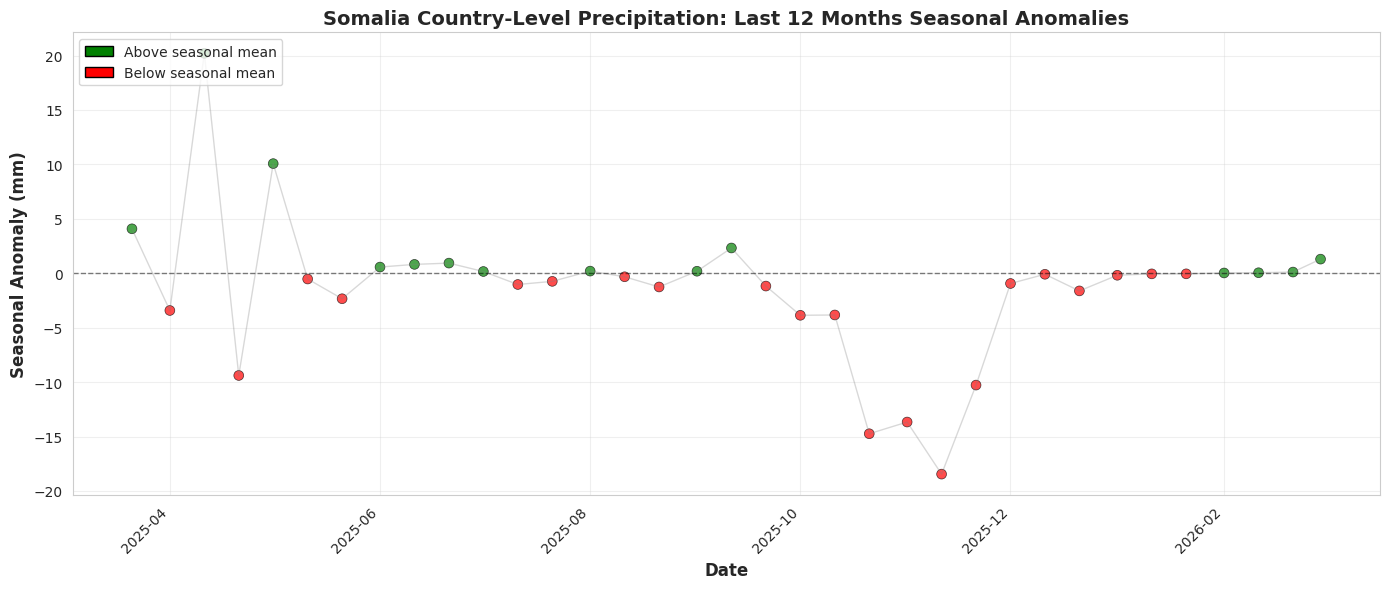


=== Country-Level Seasonal Anomaly Summary (Last 12 Months) ===
Date range: 2025-03-21 to 2026-03-01
Number of observations: 35

Anomaly Statistics:
  Mean anomaly: -1.343 mm
  Min anomaly: -18.453 mm (-85.2%)
  Max anomaly: 20.198 mm (85.8%)
  Std dev: 6.566 mm

Occurrences:
  Above seasonal mean: 14 (40.0%)
  Below seasonal mean: 21 (60.0%)

--- Recent Trend (Last 5 observations) ---
      date    value  seasonal_mean  seasonal_anomaly  seasonal_anomaly_pct
2026-01-21 0.402006       0.455647         -0.053641            -11.772447
2026-02-01 0.342027       0.316589          0.025437              8.034824
2026-02-11 0.407470       0.360587          0.046883             13.001888
2026-02-21 0.870757       0.761521          0.109236             14.344519
2026-03-01 3.483376       2.187016          1.296359             59.275233


In [15]:
# Filter to last 12 months of seasonal data
twelve_months_ago = date.today() - timedelta(days=365)
df_country_recent = df_country_seasonal[df_country_seasonal['date'] >= twelve_months_ago].copy()

# Create color map: green for above seasonal mean, red for below
colors = ['green' if x > 0 else 'red' for x in df_country_recent['seasonal_anomaly']]

# Create time series visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Plot anomalies as scatter points
ax.scatter(df_country_recent['date'], df_country_recent['seasonal_anomaly'], 
          c=colors, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

# Connect points with a line
ax.plot(df_country_recent['date'], df_country_recent['seasonal_anomaly'], 
       color='gray', alpha=0.3, linewidth=1)

# Add zero reference line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Format and labels
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Seasonal Anomaly (mm)', fontsize=12, fontweight='bold')
ax.set_title('Somalia Country-Level Precipitation: Last 12 Months Seasonal Anomalies', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Format x-axis dates
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', edgecolor='black', label='Above seasonal mean'),
                  Patch(facecolor='red', edgecolor='black', label='Below seasonal mean')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Country-Level Seasonal Anomaly Summary (Last 12 Months) ===")
print(f"Date range: {df_country_recent['date'].min()} to {df_country_recent['date'].max()}")
print(f"Number of observations: {len(df_country_recent)}")
print(f"\nAnomaly Statistics:")
print(f"  Mean anomaly: {df_country_recent['seasonal_anomaly'].mean():.3f} mm")
print(f"  Min anomaly: {df_country_recent['seasonal_anomaly'].min():.3f} mm ({df_country_recent['seasonal_anomaly_pct'].min():.1f}%)")
print(f"  Max anomaly: {df_country_recent['seasonal_anomaly'].max():.3f} mm ({df_country_recent['seasonal_anomaly_pct'].max():.1f}%)")
print(f"  Std dev: {df_country_recent['seasonal_anomaly'].std():.3f} mm")

# Count above/below seasonal mean
above_mean = len(df_country_recent[df_country_recent['seasonal_anomaly'] > 0])
below_mean = len(df_country_recent[df_country_recent['seasonal_anomaly'] < 0])

print(f"\nOccurrences:")
print(f"  Above seasonal mean: {above_mean} ({above_mean / len(df_country_recent) * 100:.1f}%)")
print(f"  Below seasonal mean: {below_mean} ({below_mean / len(df_country_recent) * 100:.1f}%)")

# Show recent trends
print(f"\n--- Recent Trend (Last 5 observations) ---")
print(df_country_recent.tail(5)[['date', 'value', 'seasonal_mean', 'seasonal_anomaly', 'seasonal_anomaly_pct']].to_string(index=False))
